In [1]:
import h5py
import numpy as np
import pandas as pd

import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
import math

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
!curl https://zenodo.org/records/2603256/files/train.h5?download=1 -o toptag_train.h5
!curl https://zenodo.org/records/2603256/files/val.h5?download=1 -o toptag_val.h5
!curl https://zenodo.org/records/2603256/files/test.h5?download=1 -o toptag_test.h5

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  990M  100  990M    0     0  18.8M      0  0:00:52  0:00:52 --:--:-- 21.0M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  20.2M      0  0:00:16  0:00:16 --:--:-- 21.2M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  15.1M      0  0:00:21  0:00:21 --:--:-- 17.4M


In [2]:
fileIN_train = "toptag_train.h5"
fileIN_val = "toptag_val.h5"
fileIN_test = "toptag_test.h5"

f_train = h5py.File(fileIN_train)
# and see what it contains
print(list(f_train.keys()))

['table']


In [3]:
df_train = pd.read_hdf(fileIN_train, 'table')
df_val = pd.read_hdf(fileIN_val, 'table')
df_test = pd.read_hdf(fileIN_test, 'table')
df_train

,E_0,PX_0,PY_0,PZ_0,E_1,PX_1,PY_1,PZ_1,E_2,PX_2,...,E_199,PX_199,PY_199,PZ_199,truthE,truthPX,truthPY,truthPZ,ttv,is_signal_new
375,474.071136,-250.347031,-223.651962,-334.738098,103.236237,-48.866222,-56.790775,-71.025490,105.255569,-55.415001,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
377,150.504532,120.062393,76.852005,-48.274265,82.257057,63.801739,42.754807,-29.454842,48.573559,36.763199,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
378,251.645386,10.427651,-147.573746,203.564880,104.147797,10.718256,-54.497948,88.101395,78.043213,5.724113,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
379,451.566132,129.885437,-99.066292,-420.984100,208.410919,59.033958,-46.177090,-194.467941,190.183304,54.069675,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
380,399.093903,-168.432083,-47.205597,-358.717438,273.691956,-121.926941,-30.803854,-243.088928,152.837219,-44.400204,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,206.171997,13.942102,114.328499,-171.001465,231.602356,19.010832,92.303848,-211.561432,95.868248,0.411594,...,0.0,0.0,0.0,0.0,1301.364624,48.551048,674.270081,-1098.891968,0,1
591,263.984161,-40.649391,-104.321312,239.065552,238.690689,8.786323,-101.236137,215.979828,126.197868,5.939164,...,0.0,0.0,0.0,0.0,1550.415405,-38.385075,-626.145813,1406.682983,0,1
592,61.417538,42.901291,43.947723,-0.436818,45.521763,31.723654,32.643845,-0.469300,44.801167,29.730831,...,0.0,0.0,0.0,0.0,654.942383,394.933441,467.778076,-162.717285,0,1
593,261.215302,12.780115,-132.699203,224.635300,224.066376,52.028233,-101.145271,193.050354,67.573616,17.166769,...,0.0,0.0,0.0,0.0,1100.826904,220.153702,-566.737549,901.328003,0,1


In [4]:
# each row of the dataframe is a jet, each constituient is a particle, the only features are the four momentum
# Converting dataframe into a usable dataset for a transformer model

class JetDataset(Dataset):

    def __init__(self, df):

        self.jets = list()
        self.labels = list()
        for index, row in df.iterrows():

            tensor = torch.tensor(row.values, dtype=torch.float)
            self.jets.append(tensor[:-6].reshape(-1, 4))
            self.labels.append(tensor[-1].item())

    def __len__(self):
        return len(self.jets)

    def __getitem__(self, index):
        return self.jets[index], self.labels[index]


In [5]:
# constituent of each jet is ordered from large to small energy
dataset_train = JetDataset(df_train)
dataset_val = JetDataset(df_val)
dataset_test = JetDataset(df_test)

In [34]:
class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, num_heads, bias = True, ln=False):
        super(MAB, self).__init__()
        self.dim_V = dim_V
        self.num_heads = num_heads
        self.fc_q = nn.Linear(dim_Q, dim_V, bias = bias)
        self.fc_k = nn.Linear(dim_K, dim_V, bias = bias)
        self.fc_v = nn.Linear(dim_K, dim_V, bias = bias)
        if ln:
            self.ln0 = nn.LayerNorm(dim_V)
            self.ln1 = nn.LayerNorm(dim_V)
        self.fc_o = nn.Linear(dim_V, dim_V, bias = bias)
        
        self.history = dict()
        
    def forward(self, Q, K):
        Q = self.fc_q(Q)
        K, V = self.fc_k(K), self.fc_v(K)
        
        dim_split = self.dim_V // self.num_heads
        Q_ = torch.cat(Q.split(dim_split, 2), 0)
        K_ = torch.cat(K.split(dim_split, 2), 0)
        V_ = torch.cat(V.split(dim_split, 2), 0)
        
        self.history["Q"] = Q_.detach()
        self.history["K"] = K_.detach()
        self.history["V"] = V_.detach()
        
        A = torch.softmax(Q_.bmm(K_.transpose(1,2))/math.sqrt(self.dim_V), 2)
        
        self.history["A"] = A.detach()
        
        O = torch.cat((Q_ + A.bmm(V_)).split(Q.size(0), 0), 2)
        O = O if getattr(self, 'ln0', None) is None else self.ln0(O)
        O = O + F.relu(self.fc_o(O))
        O = O if getattr(self, 'ln1', None) is None else self.ln1(O)
        return O

class SAB(nn.Module):
    def __init__(self, dim_in, dim_out, num_heads, ln=False, bias=True,):
        super(SAB, self).__init__()
        self.mab = MAB(dim_in, dim_in, dim_out, num_heads, ln=ln, bias=bias)

    def forward(self, X):
        return self.mab(X, X)

# A one layer transformer (one self attention block)
class SetTransformer(nn.Module):
    def __init__(self, dim_input, dim_output, num_particles_per_jet, dim_hidden=64, num_heads=8, bias=True, ln=False):
        super(SetTransformer, self).__init__()
        self.enc = nn.Sequential(
                SAB(dim_input, dim_hidden, num_heads, ln=ln, bias=bias),
              )
        self.pool = nn.AvgPool1d(num_particles_per_jet)
        self.norm = nn.BatchNorm1d(dim_hidden)
        self.fc = nn.Sequential(
            nn.Linear(dim_hidden,dim_output, bias = bias),
        )
        self.history = [self.enc[i].mab.history for i in range(len(self.enc))]
        
    def forward(self, X):
        X_ = self.pool(self.enc(X).transpose(1, 2)).squeeze(dim=-1)
        print(X_.shape)
        X_ = self.fc(self.norm(X_))
        return X_

In [35]:
torch.cuda.is_available()

True

In [63]:
# define model, dataloaders, optimizers, etc.
device = "cuda" if torch.cuda.is_available() else "cpu"

dim_in = 4
dim_output = 1
num_particles_per_jet = 200
num_heads = 4
bias = True
model = SetTransformer(dim_in, dim_output, num_particles_per_jet, num_heads = num_heads, bias = bias).to(device)

train_dataloader = DataLoader(dataset_train, batch_size=1, shuffle=True)

model.load_state_dict(torch.load('./1layer_set_transformer_topquarktag.pt'))

<All keys matched successfully>

In [64]:
X, y = next(iter(train_dataloader))
X = X.to(device)
y = y.to(device)

model(X)

torch.Size([1, 64])


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 64])

In [53]:
attention_score = (model.history[0]["Q"][0,...] @ model.history[0]["K"][0,...].T).detach().cpu().numpy()
# sns.heatmap(attention_score, annot=True, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})

In [78]:
model.history[0]["Q"][0,...] - model.enc[0].mab.fc_q.bias[:16]

tensor([[ 5.7961e+01, -1.4509e+02, -5.0348e+01,  ..., -2.8458e+01,
          4.0061e+01,  2.6638e+01],
        [ 3.5825e+01, -8.4622e+01, -2.7801e+01,  ..., -1.5463e+01,
          2.2631e+01,  1.6213e+01],
        [ 2.2984e+01, -5.7950e+01, -2.2040e+01,  ..., -9.3713e+00,
          1.3508e+01,  1.1531e+01],
        ...,
        [ 2.5818e-01, -3.7691e-01,  2.8607e-02,  ...,  1.6792e-01,
         -2.0794e-01, -4.5928e-01],
        [ 2.5818e-01, -3.7691e-01,  2.8607e-02,  ...,  1.6792e-01,
         -2.0794e-01, -4.5928e-01],
        [ 2.5818e-01, -3.7691e-01,  2.8607e-02,  ...,  1.6792e-01,
         -2.0794e-01, -4.5928e-01]], device='cuda:0')

<Axes: >

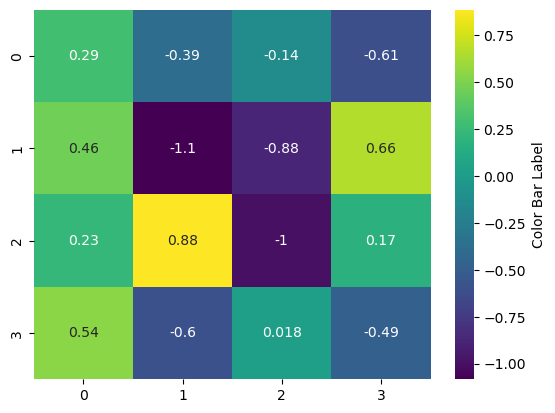

In [15]:
import seaborn as sns

attention_matrix = (model.enc[0].mab.fc_q.weight.data.T @ model.enc[0].mab.fc_k.weight.data).detach().cpu().numpy()
sns.heatmap(attention_matrix, annot=True, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})